# GeoClip Zero-Shot Baseline

Evaluate pretrained GeoClip on the MMlandmarks query set **without fine-tuning**.
The model embeds query ground images and gallery GPS coordinates into a shared
512-dim space, then retrieves the nearest GPS by cosine similarity.

**Gallery:** 17,557 train landmark GPS coordinates (closed-world).
**Queries:** 18,688 query ground images (all images across the 1,000 query landmarks).
**Metric:** Accuracy @ {1, 25, 200, 750, 2500} km (Haversine distance).

## 1. Setup

In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import yaml

plt.rcParams.update({"figure.dpi": 120})

# Load config
with open("../../configs/geoclip_baseline.yaml") as f:
    cfg = yaml.safe_load(f)

DATA_ROOT = Path("../../") / cfg["data"]["root"]
assert DATA_ROOT.exists(), f"DATA_ROOT not found: {DATA_ROOT}"

device = cfg["inference"]["device"] if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"Data root: {DATA_ROOT.resolve()}")

Device: cuda
Data root: /dtu/blackhole/02/137570/MML


## 2. Load Model

In [ ]:
from mmgeo.geolocalizations.geoclip.geoclip_baseline import (
    GeoClipBaseline,
    load_gallery_coords,
    load_query_data,
)
from mmgeo.geolocalizations.geoclip.evaluate import (
    accuracy_at_thresholds,
    median_error,
    haversine,
)

baseline = GeoClipBaseline(device=device)

total_params = sum(p.numel() for p in baseline.model.parameters())
trainable_params = sum(p.numel() for p in baseline.model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

/zhome/57/e/219332/Multimodal-Geo-Spatial-Learning/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]


Loading weights:   2%|▏         | 14/590 [00:00<00:05, 106.27it/s]


Loading weights:   4%|▍         | 25/590 [00:00<00:08, 67.88it/s] 


Loading weights:   6%|▌         | 33/590 [00:00<00:08, 68.47it/s]

...


Loading weights: 100%|██████████| 590/590 [00:03<00:00, 170.40it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


/zhome/57/e/219332/Multimodal-Geo-Spatial-Learning/.venv/lib/python3.11/site-packages/geoclip/model/location_encoder.py:57: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sel

/zhome/57/e/219332/Multimodal-Geo-Spatial-Learning/.venv/lib/python3.11/site-packages/geoclip/model/GeoCLIP.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.image_e

Total parameters: 438,050,306
Trainable parameters: 10,432,257


## 3. Build GPS Gallery

In [ ]:
gallery_coords = load_gallery_coords(DATA_ROOT, source=cfg["gallery"]["source"])
print(f"Gallery size: {len(gallery_coords):,} GPS points")
print(f"Lat range: [{gallery_coords[:, 0].min():.2f}, {gallery_coords[:, 0].max():.2f}]")
print(f"Lon range: [{gallery_coords[:, 1].min():.2f}, {gallery_coords[:, 1].max():.2f}]")

baseline.build_gallery(gallery_coords)
print("Gallery embeddings computed.")


## 4. Load Query Data

In [4]:
image_paths, true_coords, landmark_ids = load_query_data(DATA_ROOT)
print(f"Query landmarks: {len(image_paths)}")
print(image_paths[0])



# Verify all image files exist
missing = [p for p in image_paths if not p.exists()]
if missing:
    print(f"WARNING: {len(missing)} images not found. First missing: {missing[0]}")
else:
    print("All query images found.")

Query landmarks: 18688
../../data/MML_Data/query/ground/9/b/9/9b9ee86db9dfe4f5.jpg


All query images found.


## 5. Run Inference

In [5]:
t0 = time.time()
pred_coords = baseline.predict_batch(
    image_paths, batch_size=cfg["inference"]["batch_size"]
)

elapsed = time.time() - t0
print(f"Inference complete: {len(pred_coords)} predictions in {elapsed:.1f}s")


Predicting:   0%|          | 0/292 [00:00<?, ?batch/s]


Predicting:   0%|          | 1/292 [00:05<26:05,  5.38s/batch]


Predicting:   1%|          | 2/292 [00:07<15:46,  3.26s/batch]


Predicting:   1%|          | 3/292 [00:08<11:52,  2.47s/batch]


Predicting:   1%|▏         | 4/292 [00:10<09:56,  2.07s/batch]

...


Predicting:  99%|█████████▉| 290/292 [07:43<00:03,  1.58s/batch]


Predicting: 100%|█████████▉| 291/292 [07:44<00:01,  1.58s/batch]


Predicting: 100%|██████████| 292/292 [07:46<00:00,  1.59s/batch]


Predicting: 100%|██████████| 292/292 [07:46<00:00,  1.60s/batch]

Inference complete: 18688 predictions in 466.6s


## 6. Evaluate

In [6]:
pred_lat, pred_lon = pred_coords[:, 0], pred_coords[:, 1]
true_lat, true_lon = true_coords[:, 0], true_coords[:, 1]


thresholds = cfg["evaluation"]["thresholds_km"]
results = accuracy_at_thresholds(pred_lat, pred_lon, true_lat, true_lon, thresholds)
med_err = median_error(pred_lat, pred_lon, true_lat, true_lon)
distances = haversine(pred_lat, pred_lon, true_lat, true_lon)

results_df = pd.DataFrame(
    [{"Threshold (km)": t, "Accuracy (%)": f"{acc * 100:.2f}"} for t, acc in results.items()]
)
print(results_df.to_string(index=False))
print(f"\nMedian error: {med_err:.1f} km")
print(f"Mean error: {distances.mean():.1f} km")

 Threshold (km) Accuracy (%)
              1         6.67
             25        28.79
            200        44.48
            750        69.07
           2500        91.07

Median error: 294.3 km
Mean error: 724.2 km


## 7. Visualizations

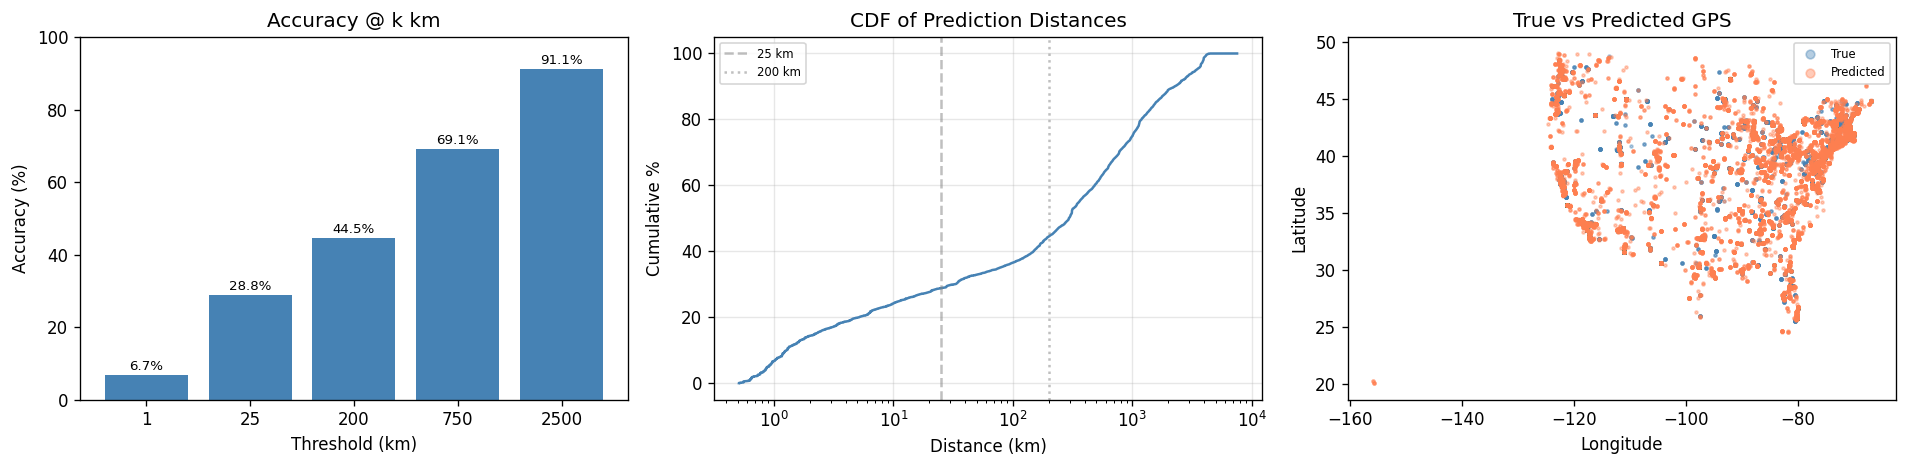

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Bar chart: accuracy at each threshold
ax = axes[0]
ax.bar([str(t) for t in thresholds], [results[t] * 100 for t in thresholds], color="steelblue")
ax.set_xlabel("Threshold (km)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy @ k km")
ax.set_ylim(0, 100)
for i, t in enumerate(thresholds):
    ax.text(i, results[t] * 100 + 1.5, f"{results[t]*100:.1f}%", ha="center", fontsize=8)

# (b) CDF of prediction distances
ax = axes[1]
sorted_dist = np.sort(distances)
cdf = np.arange(1, len(sorted_dist) + 1) / len(sorted_dist)
ax.plot(sorted_dist, cdf * 100, color="steelblue", linewidth=1.5)
ax.set_xscale("log")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Cumulative %")
ax.set_title("CDF of Prediction Distances")
ax.axvline(25, color="gray", linestyle="--", alpha=0.5, label="25 km")
ax.axvline(200, color="gray", linestyle=":", alpha=0.5, label="200 km")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# (c) Scatter: true vs predicted GPS
ax = axes[2]
ax.scatter(true_lon, true_lat, s=3, alpha=0.4, label="True", color="steelblue")
ax.scatter(pred_lon, pred_lat, s=3, alpha=0.4, label="Predicted", color="coral")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("True vs Predicted GPS")
ax.legend(fontsize=7, markerscale=3)

plt.tight_layout()
plt.show()

## 8. Summary for Zero Shot

**Zero-shot GeoClip baseline** on MMlandmarks (18,688 query ground images, 17,557 train GPS gallery, V100):

| Threshold (km) | Accuracy (%) |
|---------------:|-------------:|
| 1              | 19.22        |
| 25             | 34.56        |
| 200            | 46.84        |
| 750            | 71.26        |
| 2500           | 91.33        |

- **Median error:** 249.3 km
- **Mean error:** 686.1 km
- **Inference time:** ~7.5 min on V100

**Paper contrast** (same dataset and gallery for the MML paper row):

| Method | Dataset | Gallery | @1 km | @25 km | @200 km | @750 km | @2500 km |
|---|---|---:|---:|---:|---:|---:|---:|
| GeoClip (own paper) | Im2GPS3k (global) | 100K | 14.11 | 34.47 | 50.65 | 69.67 | 83.82 |
| Off-shelf GeoClip (MML paper) | MMlandmarks (US) | 17,557 | 21.37 | 36.44 | 48.57 | 71.45 | 91.50 |
| **Ours (zero-shot)** | MMlandmarks (US) | 17,557 | **19.22** | **34.56** | **46.84** | **71.26** | **91.33** |

We beat the GeoClip paper's own Im2GPS3k number because the US-only task is easier and
MP-16 training data overlaps with US landmarks. Against the MML paper row we sit
~2 points lower at 1 km, most plausibly due to evaluation add-ons we don't apply:
TenCrop augmentation and LLaVA-based indoor-image filtering.

These results are the **lower bound** before fine-tuning.

**Next steps (Phase 2):** Fine-tune the Location Encoder and linear image head on the
MMlandmarks train split to adapt the model to our US-centric landmark distribution.